# <font color='red'>ML assignment - Part 1</font>

This notebook contains  step-by-step exercises inspired by what done in the lecture (namely: the **MNIST2A** ipynb).

The goal is to build yourself a simple but working **Multi-Layer Perceptron (MLP)** for classifying handwritten digits from the MNIST dataset.

Each step contains:

- a task OR a question;
- a code cell to fill OR a text/markdown cell to fill.

You can/should copy from the ipynb used at the lectures, adapt as needed by modifying the code, and go step-by-step to build your own solution, and deliver it as the teacher has explained.

## Step 0 — Import the basic libraries

**Task.** Import the Python libraries needed for this notebook:

- `numpy` for numerical operations;
- `matplotlib.pyplot` for plotting;
- `tensorflow.keras` tools for loading MNIST and building the neural network.

In [67]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

## Step 1 — Load the MNIST dataset

**Task.** Load the MNIST dataset.

MNIST should be  split into:

- training images and labels;
- test images and labels.

In [68]:
from keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Step 2 — Inspect the dataset and visualize some digits

**Task.** Check at least:

- the shape of the training images;
- the shape of the test images;
- the number of labels;
- the data type of the images.

This helps us understand the input format before building the neural network.

**Task.** Display at least one image from the training set and print its label.

In [76]:
print(train_images.shape)
print(test_images.shape)
print(len(train_labels))
print(len(test_labels))
print(train_images.dtype)
print(test_images.dtype)
print(train_labels[156])
train_images[156]

(60000, 28, 28)
(10000, 28, 28)
60000
10000
uint8
uint8
0


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         32,  57,  57,  57,  57,  57,  57,  57,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  67, 185,
        229, 252, 252, 252, 253, 252, 252, 252, 185,  66,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  13, 188, 246, 252,
        253, 252, 252, 252, 241, 139, 177, 252, 253, 246, 187,  13,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  26, 255, 253, 244, 175,
        101,   0,   0,   0,   0,   0,   0,   0, 126, 244, 253, 153,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  82, 243, 253, 214,  81,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0, 169, 252, 252,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  19, 215, 252, 206,  56,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0, 169, 252, 252,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 157, 252, 252,  13,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0, 169, 252, 151,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  41, 253, 253, 128,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,  92, 253, 206,  13,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 166, 252, 196,   9,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0, 216, 252, 142,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 253, 252, 168,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,  89, 253, 208,  13,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 253, 252,  68,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,  38, 225, 253,  96,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 254, 253,  56,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,  45, 229, 253, 151,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 253, 252,  81,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  70, 225, 252, 227,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 216, 252, 168,   0,   0,   0,   0,   0,
          0,   0,  29, 134, 253, 252, 186,  31,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  91, 252, 243, 125,   0,   0,   0,  51,
        114, 113, 210, 252, 253, 151,  19,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 157, 253, 253, 254, 253, 253, 253,
        254, 253, 244, 175,  51,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  19, 122, 196, 197, 221, 196, 196,
        197, 121,  56,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  25,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

## Step 3 — Reshape the images and apply feature scaling

**Task.** Reshape the 28 × 28 images to a flat vector.
**bold text**
**Task.** Convert the pixel values from integers in the range `[0, 255]` to floating-point numbers in the range `[0, 1]`.

In [77]:
train_images = train_images.reshape(train_images.shape[0], -1)
train_images = train_images.astype('float32') / 255
test_images = test_images.reshape(test_images.shape[0], -1)
test_images = test_images.astype('float32') / 255

## Step 4 — Answer this question

**Question.** Why are you reshaping?


Because common machine learning processes work with flat vectors, therefore we need to give them data that they can elaborate.

## Step 5 — Answer this question

**Question.** Why are you converting pixel values?

To normalize the range of the operations


## Step 6 — Build a simple MLP model

**Task.** Build a simple neural network with:

- one hidden `Dense` layer with 128 neurons and ReLU activation;
- one output `Dense` layer with 10 neurons and softmax activation.


In [78]:
from keras import models
from keras import layers
brain = models.Sequential([
  layers.Dense(128, activation='relu'),
  layers.Dense(10, activation='softmax')
])

## Step 7 — Answer this question

**Question.** Why are we using 10 neurons in the final layer?

Because the network will associate an image to a number from 0 to 9. So, since our model has 10 possible choices, the network will give us in output the probability of the image being any of those numbers.


## Step 8 — Answer this question

**Question.** Why is `softmax` appropriate for the output layer?

Because softmax is a function that takes in input an array of data and gives in output an array of numbers whose sum is 1. It's therefore perfect to represent a probability.


## Step 9 — Compile the model

**Task.** Compile the model by choosing:

- `rmsprop` as optimizer;
- `sparse_categorical_crossentropy` as loss;
- `accuracy` as metric.

In [79]:
brain.compile(optimizer='rmsprop',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

## Step 10 — Train the model

**Task.** Train the model with these instructions:

- train for just 5 epochs;
- divide the full training set in batches of 128 examples each;
- use a validation set, 20% the size of the total dataset
- save the result into a variable called `history` so thyou can inspect the training curves later
- make sure you measure how long it takes to train

In [80]:
%%time
history=brain.fit(train_images, train_labels, epochs=5, batch_size=128, validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8980 - loss: 0.3728 - val_accuracy: 0.9380 - val_loss: 0.2150
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9477 - loss: 0.1812 - val_accuracy: 0.9552 - val_loss: 0.1581
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9624 - loss: 0.1299 - val_accuracy: 0.9642 - val_loss: 0.1239
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9713 - loss: 0.1010 - val_accuracy: 0.9693 - val_loss: 0.1093
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9770 - loss: 0.0816 - val_accuracy: 0.9713 - val_loss: 0.0997
CPU times: user 8.74 s, sys: 983 ms, total: 9.72 s
Wall time: 7.61 s


## Step 11 — Plot the training history

**Task.** Plot the training and validation accuracy across epochs.

<Axes: >

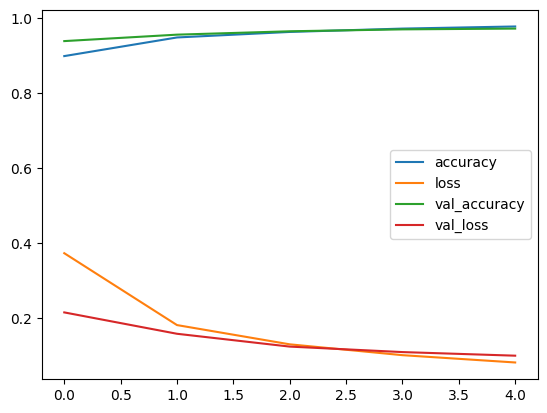

In [81]:
pd.DataFrame(history.history).plot()

## Step 12 — Answer this question

**Question.** Comment on the plot you just made. What do you observe?

As desired, the accuracies increase with the number of epochs, while the loss decreases. There's no sign of overfitting.


## Step 13 — Evaluate the model on the test set

**Task.** Compute the final test loss and test accuracy.

In [82]:
test_loss, test_acc = brain.evaluate(test_images, test_labels)
print('test_loss:', test_loss)
print('test_acc:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9728 - loss: 0.0933
test_loss: 0.09329751878976822
test_acc: 0.9728000164031982


## Step 14 — Make predictions

**Task.** Use the trained model to predict the class of a test image.

In [162]:
print(brain.predict(test_images[4:5]))
test_labels[4:5]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[1.7062668e-04 2.5107538e-06 4.3455148e-04 2.3623055e-05 9.3908030e-01
  1.5240821e-05 2.9160664e-04 4.3583018e-04 4.1664479e-04 5.9129104e-02]]


array([4], dtype=uint8)

## Step 15 — Inspect wrong predictions

**Task.** Find a few test images that the model classifies incorrectly. You can write code to find it, or go but trying some and find one by just multiple attempts.

In [192]:
print(brain.predict(test_images[8:9]))
print(test_labels[8:9])
c=1
for i in brain.predict(test_images[8:9]):
  max=i[test_labels[8:9]]
  print(max)
  for k in [0,9]:
    print(i[k])
    if k != test_labels[8:9]:
      if i[k] > max:
        kmax=k
        max=i[k]
        if k==9:
          print("Error in image number", c)
          print("Predicted image is", kmax)
          print("True image is", test_labels[8:9][i])
  c=c+1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[5.8250342e-05 2.6252002e-07 4.9045811e-05 8.9270934e-06 5.9569412e-04
  2.1175710e-02 9.7778141e-01 2.6919658e-08 2.6115577e-04 6.9433401e-05]]
[5]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[0.02117571]
5.825034e-05
6.94334e-05


## Step 16 — Explore modification to the model capacity

**Task.** Try a slightly different MLP architecture, e.g.

- increase the hidden layer from 128 to 256 neurons;
- add a second hidden layer with 128 neurons;
- compare test accuracy with the one from your previous model.

In [ ]:
# add your code here

## Step 17 — Simulate overfitting with less training data

**Task.** Train a relatively large model (i.e. last one? a larger one? you choose!) on a *smaller* subset of the training data. Plot training and validation accuracy, and compare them with the ones you plotted previously.


In [ ]:
# add your code here

## Step 18 — Answer this question

**Question.** Comment on what you observe in such plots comparison.

**Answer.** Insert here your *answer*


## Step 19 - Answer this final reflection question

**Question.** Which is the best accuracy you were able to get?

**Question.** To close on this, in a nutshell, what did you learn by splitting our dataset into training, validation and test? what is ultimately the difference between training accuracy, validation accuracy, and test accuracy? What signs may indicate overfitting?

**Answer.** Insert here your *answers* to previous questions.


## Step 20 - (NOT MANDATORY) Explore the (possibly) best world-wide solution for this problem


**Task.** The (possibly) best code for a MLP on MNIST is in the notebok called **reference strong MLP solution**.

Note that are way more tricks and nice features! But you should be able to read through it, understand most of it, guess what some stuff is, and you can google for the meaning of anything that really looks unfamiliar.

Experiment with it separately, and write down below your observations. If you do not do this part (indeed, NOT MANDATORY), just fill the part below with the text "I did not do this part".

**Answer.** Insert here your *answer*.